In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# فصل ۷ — ماشین‌های بردار پشتیبان (SVM)
## درس ۲: توابع کرنل در SVM

**هدف:** درک این‌که *کرنل* چیست، چرا کار می‌کند، چه کرنل‌هایی در عمل رایج هستند، و انتخاب کرنل چگونه مرز تصمیم و تعمیم‌پذیری SVM را روی داده‌های جدولی واقعی تغییر می‌دهد.

### اهداف یادگیری

در پایان این درس باید بتوانید:

1. **ترفند کرنل** را به‌عنوان محاسبه‌ی ضرب داخلی در یک فضای ویژگی ضمنی توضیح دهید.
2. تشخیص دهید چه زمانی یک تابع شباهت، **کرنل معتبر** است (نیمه‌معین مثبت / شرط مرسر).
3. **تابع تصمیم کرنلی‌شده‌ی SVM** را از فرم دوگان استخراج کنید و نقش بردارهای پشتیبان را بفهمید.
4. کرنل‌های رایج (خطی، چندجمله‌ای، RBF/گاوسی، سیگموید) را مقایسه کرده و ابرپارامترهای آن‌ها را تفسیر کنید.
5. در پایتون و با `scikit-learn` کرنل SVM را پیاده‌سازی کنید، شامل:
   - مقیاس‌بندی + پایپلاین،
   - اعتبارسنجی متقاطع برای $(C, \gamma, d, \text{coef0})$،
   - ماتریس گرام از پیش‌محاسبه‌شده،
   - مرکزدهی ماتریس گرام،
   - تقریب کرنل (Random Fourier Features).

برای این‌که فقط به یک دیتاست تکیه نکنیم، از چند دیتاست داخل ساختار ریپوی شما (Iris، Glass، Diabetes، Stars) استفاده می‌کنیم.

### ۱) مرور سریع: کرنل دقیقاً کجا در SVM ظاهر می‌شود؟

برای دسته‌بندی دودویی، داده‌های آموزشی $\{(x_i, y_i)\}_{i=1}^n$ را در نظر بگیرید که $x_i \in \mathbb{R}^p$ و برچسب‌ها $y_i \in \{-1,+1\}$ هستند.

فرم پرایمال SVM با **حاشیه‌ی نرم**:

$$
\begin{aligned}
\min_{w,b,\xi} \quad & \frac{1}{2}\|w\|^2 + C \sum_{i=1}^n \xi_i \\
\text{s.t.}\quad & y_i (w^\top x_i + b) \ge 1 - \xi_i,\quad i=1,\dots,n \\
& \xi_i \ge 0.
\end{aligned}
$$

تفسیر:

- $\|w\|$ پهنای حاشیه را کنترل می‌کند (حاشیه‌ی بزرگ‌تر $\Rightarrow$ $\|w\|$ کوچک‌تر)،
- $\xi_i$ اجازه‌ی نقض حاشیه را می‌دهند،
- $C$ تعادل بین حاشیه و خطای آموزش است.

#### اسکچ لاگرانژ و KKT

لاگرانژ‌گران‌ها: $\alpha_i \ge 0$ برای قیود
$y_i (w^\top x_i + b) \ge 1 - \xi_i$ و $\mu_i \ge 0$ برای $\xi_i \ge 0$.

لاگرانژ:

$$
\mathcal{L}(w,b,\xi,\alpha,\mu)
= \frac{1}{2}\|w\|^2 + C\sum_i \xi_i
- \sum_i \alpha_i\left(y_i(w^\top x_i + b) - 1 + \xi_i\right)
- \sum_i \mu_i \xi_i.
$$

شرط‌های ایستایی:

- $\frac{\partial \mathcal{L}}{\partial w}=0 \Rightarrow w = \sum_i \alpha_i y_i x_i$
- $\frac{\partial \mathcal{L}}{\partial b}=0 \Rightarrow \sum_i \alpha_i y_i = 0$
- $\frac{\partial \mathcal{L}}{\partial \xi_i}=0 \Rightarrow C - \alpha_i - \mu_i = 0 \Rightarrow 0 \le \alpha_i \le C$

پس فرم دوگان:

$$
\begin{aligned}
\max_{\alpha}\quad & \sum_{i=1}^n \alpha_i - \frac{1}{2}\sum_{i=1}^n\sum_{j=1}^n \alpha_i\alpha_j y_i y_j \, (x_i^\top x_j) \\
\text{s.t.}\quad & 0 \le \alpha_i \le C,\quad i=1,\dots,n \\
& \sum_{i=1}^n \alpha_i y_i = 0.
\end{aligned}
$$

مشاهده‌ی حیاتی: داده‌ها فقط از طریق ضرب داخلی $x_i^\top x_j$ وارد می‌شوند. همین موضوع امکان کرنلی‌سازی را فراهم می‌کند.

### ۲) نگاشت ویژگی و ترفند کرنل

یک نگاشت غیرخطی در نظر بگیرید:

$$
\phi:\mathbb{R}^p \to \mathcal{H},
$$

که $\mathcal{H}$ می‌تواند هیلبرت بسیار بزرگ (حتی بی‌نهایت‌بعدی) باشد.

در دوگان، ضرب داخلی به شکل $\langle \phi(x_i), \phi(x_j)\rangle$ ظاهر می‌شود. **کرنل** را تعریف می‌کنیم:

$$
k(x,z) := \langle \phi(x), \phi(z)\rangle_{\mathcal{H}}.
$$

پس کافی است جایگزینی زیر را انجام دهیم:

$$
x_i^\top x_j \;\;\longrightarrow\;\; k(x_i,x_j)
$$

که همان **ترفند کرنل** است.

#### تابع تصمیم کرنلی‌شده

از رابطه‌ی $w = \sum_i \alpha_i y_i \phi(x_i)$ داریم:

$$
\begin{aligned}
g(x) &= \langle w, \phi(x)\rangle + b
= \sum_i \alpha_i y_i \langle \phi(x_i), \phi(x)\rangle + b \\
&= \sum_i \alpha_i y_i k(x_i,x) + b,
\end{aligned}
$$

و در نتیجه:

$$
f(x) = \text{sign}(g(x)).
$$

فقط نمونه‌هایی با $\alpha_i>0$ اثر دارند؛ این‌ها **بردارهای پشتیبان** هستند.

#### قضیه‌ی نمایش‌گر (Representer Theorem)

در بسیاری از مسائل ریسک تجربی منظم‌سازی‌شده در RKHS، جواب به صورت:

$$
f(\cdot) = \sum_{i=1}^n c_i\, k(x_i, \cdot)
$$

خواهد بود.

**اسکچ اثبات:** $f$ را به مؤلفه‌ی موازی با اسپن $\{k(x_i,\cdot)\}$ و مؤلفه‌ی عمود تجزیه کنید. به دلیل خاصیت بازتولیدکنندگی، مؤلفه‌ی عمود روی نقاط آموزش صفر است، پس زیان فقط به مؤلفه‌ی موازی وابسته است، اما نُرم RKHS با اضافه کردن مؤلفه‌ی عمود بزرگ‌تر می‌شود. بنابراین مینیمم‌کننده باید مؤلفه‌ی عمود صفر داشته باشد.

این دقیقاً توضیح می‌دهد چرا روش‌های کرنلی به شکل جمع روی نمونه‌های آموزش ظاهر می‌شوند (در SVM: بردارهای پشتیبان).

### ۳) چه زمانی یک تابع، کرنل معتبر است؟ (PSD / مرسر)

هر تابع شباهتی کرنل معتبر نیست.

$k(x,z)$ اگر متقارن باشد و برای هر مجموعه‌ی محدود $\{x_1,\dots,x_n\}$، ماتریس گرام

$$
K_{ij} = k(x_i,x_j)
$$

نیمه‌معین مثبت باشد، یک کرنل PSD است:

$$
c^\top K c \ge 0 \quad \forall c \in \mathbb{R}^n.
$$

این شرط معادل نامنفی بودن مقادیر ویژه‌ی $K$ است.

#### بیان رسمی‌تر قضیه‌ی مرسر

برای کرنل پیوسته و متقارن و PSD روی یک دامنه‌ی فشرده:

$$
k(x,z) = \sum_{m=1}^{\infty} \lambda_m \, \psi_m(x)\psi_m(z),
$$

که $\lambda_m \ge 0$ هستند. پس می‌توان نگاشت ویژگی را به صورت:

$$
\phi(x) = (\sqrt{\lambda_1}\psi_1(x), \sqrt{\lambda_2}\psi_2(x), \dots)
$$

تعریف کرد تا $k(x,z)=\langle \phi(x), \phi(z)\rangle$.

#### طراحی کرنل با خاصیت‌های بسته بودن

کرنل‌های PSD تحت جمع، ضرب، ضرب در ثابت نامنفی و ترکیب نگاشت ویژگی بسته هستند؛ بنابراین ساخت کرنل‌های جدید با اطمینان ممکن است.

بعداً یک بررسی عددی PSD با مقادیر ویژه انجام می‌دهیم.

### ۴) چرا کرنل‌های رایج PSD هستند؟ (ایده‌های اثبات)

#### ۴.۱ کرنل چندجمله‌ای PSD است

$$
k(x,z) = (x^\top z + r)^d
$$

با $d\ge 1$ صحیح و $r\ge 0$.

با بسط دوجمله‌ای:

$$
(x^\top z + r)^d = \sum_{m=0}^d \binom{d}{m} r^{d-m} (x^\top z)^m.
$$

و می‌دانیم $(x^\top z)^m$ ضرب داخلی تانسوری است:

$$
(x^\top z)^m = \langle x^{\otimes m}, z^{\otimes m}\rangle.
$$

پس مجموع وزن‌دار نامنفی از ضرب‌های داخلی، خود یک ضرب داخلی در فضای جمع مستقیم است؛ بنابراین کرنل چندجمله‌ای PSD است. با $\gamma\ge 0$ نیز:

$$
(\gamma x^\top z + r)^d
$$

همچنان PSD باقی می‌ماند.

#### ۴.۲ کرنل RBF PSD است

کرنل:

$$
k(x,z) = \exp(-\gamma\|x-z\|^2)
$$

ایستا است. طبق **قضیه‌ی بوخنر**، کرنل‌های ایستا PSD هستند اگر تبدیل فوریه‌ی آن‌ها نامنفی باشد. تبدیل فوریه‌ی گاوسی نیز گاوسی و نامنفی است؛ پس RBF برای $\gamma>0$ PSD است.

#### ۴.۳ نکته درباره‌ی سیگموید

کرنل سیگموید برای همه‌ی پارامترها PSD نیست، بنابراین تضمین‌های کوژ بودن همیشه برقرار نیست.

---

### ۵) مرکزدهی و نرمال‌سازی کرنل (پیشرفته اما مفید)

برای برخی کاربردها می‌توان کرنل را در فضای ویژگی مرکزدهی کرد:

$$
K_c = H K H,\quad H = I - \frac{1}{n}\mathbf{1}\mathbf{1}^\top.
$$

همچنین نرمال‌سازی به واحد کردن قطر کرنل کمک می‌کند:

$$
\tilde{k}(x,z)=\frac{k(x,z)}{\sqrt{k(x,x)k(z,z)}}.
$$

### ۶) کرنل‌های رایج و تفسیر

**خطی:**
$$
k(x,z)=x^\top z
$$

**چندجمله‌ای:**
$$
k(x,z)=(\gamma x^\top z + r)^d
$$

**RBF/گاوسی:**
$$
k(x,z)=\exp(-\gamma\|x-z\|^2)
$$

**سیگموید:**
$$
k(x,z)=\tanh(\gamma x^\top z + r)
$$

در RBF، $\gamma$ میزان محلی بودن را کنترل می‌کند و در نتیجه پیچیدگی مرز تصمیم را تغییر می‌دهد.

---

### ۷) مقیاس‌بندی و شهود $C$–$\gamma$

به دلیل وابستگی کرنل‌ها به فاصله یا ضرب داخلی، مقیاس‌بندی ویژگی‌ها حیاتی است. در RBF:

$$
\|x-z\|^2=\sum_j (x_j-z_j)^2
$$

پس یک ویژگی با مقیاس بزرگ می‌تواند همه‌چیز را غالب کند.

در این نوت‌بوک از پایپلاین استفاده می‌کنیم:

`Pipeline([("scaler", StandardScaler()), ("svc", SVC(...))])`

**شهود:**
- $C$ بزرگ $\Rightarrow$ خطای آموزش کمتر، احتمال بیش‌برازش بیشتر،
- $\gamma$ بزرگ $\Rightarrow$ مرز تصمیم محلی‌تر و پیچیده‌تر.

وقتی هر دو بزرگ باشند، بیش‌برازش محتمل است.

### ۸) راهنمای عملی انتخاب کرنل

1. **همیشه با پایپلاین شروع کنید**: مقیاس‌بندی/کدگذاری + مدل.
2. اگر $n$ خیلی بزرگ است، به گزینه‌های مقیاس‌پذیر فکر کنید:
   - SVM خطی (`LinearSVC`)، یا
   - تقریب کرنل (RFF)، یا
   - روش‌های تقریبی دیگر (مثل Nyström).
3. برای ویژگی‌های دسته‌ای:
   - `OneHotEncoder` و سپس مقایسه با کرنل خطی به عنوان baseline.
4. انتخاب ابرپارامترها را با CV انجام دهید:
   - برای خطی: $C$،
   - برای RBF: $(C,\gamma)$،
   - برای چندجمله‌ای: $(C,\gamma,d,\text{coef0})$.
5. از نشت داده جلوگیری کنید: fit فقط روی داده‌ی آموزش/فولد آموزش (پایپلاین این را درست انجام می‌دهد).
6. بسته به مسئله، معیار ارزیابی را درست انتخاب کنید؛ در این درس برای سادگی از accuracy استفاده می‌کنیم.

## ۹) مثال‌ها (با چند دیتاست از ساختار ریپو)

در این درس چند آزمایش کرنلی انجام می‌دهیم:

- **Iris**: نمایش بصری اثر کرنل‌ها در ۲ بعد.
- **Iris gamma sweep**: مشاهده‌ی تغییر پیچیدگی با $\gamma$.
- **Glass**: چندکلاسه و مقایسه‌ی کرنل‌ها.
- **Diabetes**: انتخاب کرنل و ابرپارامتر با CV.
- **Stars**: ترکیب ویژگی‌های عددی و دسته‌ای با One-Hot Encoding.
- **کرنل سفارشی**: ساخت ماتریس گرام، بررسی PSD، آموزش با `kernel="precomputed"`.
- **RFF**: تقریب RBF و مقایسه با RBF دقیق.

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.svm import SVC, LinearSVC
from sklearn.kernel_approximation import RBFSampler

In [3]:
# Dataset paths (relative to the notebook location)
PATH_IRIS = "../../../Datasets/Classification/iris.csv"
PATH_GLASS = "../../../Datasets/Classification/glass.csv"
PATH_DIABETES = "../../../Datasets/Classification/diabetes.csv"
PATH_STARS = "../../../Datasets/Classification/stars.csv"

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
from sklearn.preprocessing import LabelEncoder

def load_csv(path):
    # Load a CSV with pandas (relative paths expected by repo structure).
    return pd.read_csv(path)

def train_test_report(clf, X_train, X_test, y_train, y_test, title=""):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print("="*80)
    if title:
        print(title)
        print("-"*80)
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification report:")
    # zero_division=0 avoids UndefinedMetricWarning when a class gets no predicted samples
    print(classification_report(y_test, y_pred, zero_division=0))
    return y_pred

def plot_decision_boundary_2d(model, X, y, feature_names=("x1","x2"), title="Decision boundary"):
    """Plot decision regions for 2D features.

    Important: `model.predict(...)` may return *string labels*.
    Matplotlib's contourf expects numeric arrays, so we encode class labels to integers.
    """
    le = LabelEncoder().fit(y)

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z_pred = model.predict(grid)
    Z_enc = le.transform(Z_pred).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    levels = np.arange(len(le.classes_) + 1) - 0.5
    plt.contourf(xx, yy, Z_enc, alpha=0.25, levels=levels)

    for cls in le.classes_:
        mask = (y == cls)
        plt.scatter(X[mask, 0], X[mask, 1], s=20, label=str(cls))

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(title)
    plt.legend()
    plt.show()

def gram_matrix(X, kernel_fn):
    # Compute Gram matrix K_ij = k(x_i, x_j).
    n = X.shape[0]
    K = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(n):
            K[i, j] = kernel_fn(X[i], X[j])
    return K

def center_gram(K):
    # Center a Gram matrix in feature space: Kc = H K H, H = I - (1/n)11^T
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n))/n
    return H @ K @ H

def is_psd(K, tol=1e-10):
    # Check PSD by eigenvalues (numerical tolerance).
    Ksym = 0.5 * (K + K.T)
    eigvals = np.linalg.eigvalsh(Ksym)
    return eigvals.min() >= -tol, eigvals


,sepal_length,sepal_width,petal_length,petal_width,classification
0,5.4,3.7,1.5,0.2,Iris-setosa
1,4.8,3.4,1.6,0.2,Iris-setosa
2,4.8,3.0,1.4,0.1,Iris-setosa
3,4.3,3.0,1.1,0.1,Iris-setosa
4,5.8,4.0,1.2,0.2,Iris-setosa


Iris 2D — kernel=linear
--------------------------------------------------------------------------------
Accuracy: 0.7105

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.92      0.96        12
Iris-versicolor       0.56      0.69      0.62        13
 Iris-virginica       0.64      0.54      0.58        13

       accuracy                           0.71        38
      macro avg       0.73      0.72      0.72        38
   weighted avg       0.73      0.71      0.71        38



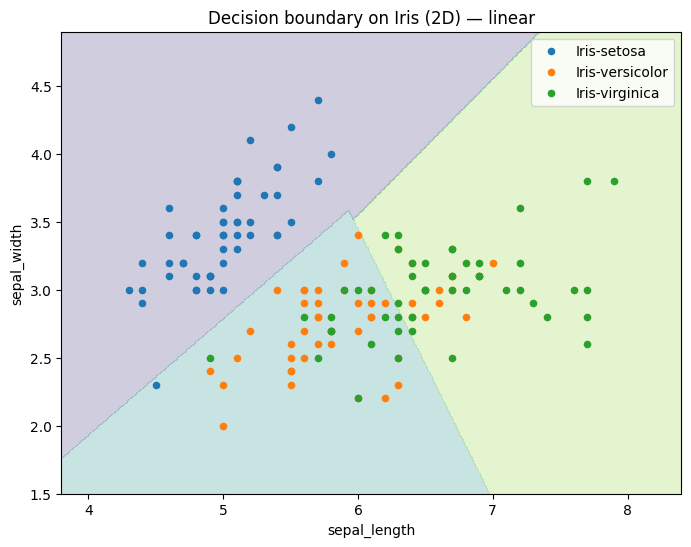

Iris 2D — kernel=poly(d=3)
--------------------------------------------------------------------------------
Accuracy: 0.6316

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.92      0.96        12
Iris-versicolor       0.47      0.69      0.56        13
 Iris-virginica       0.50      0.31      0.38        13

       accuracy                           0.63        38
      macro avg       0.66      0.64      0.63        38
   weighted avg       0.65      0.63      0.62        38



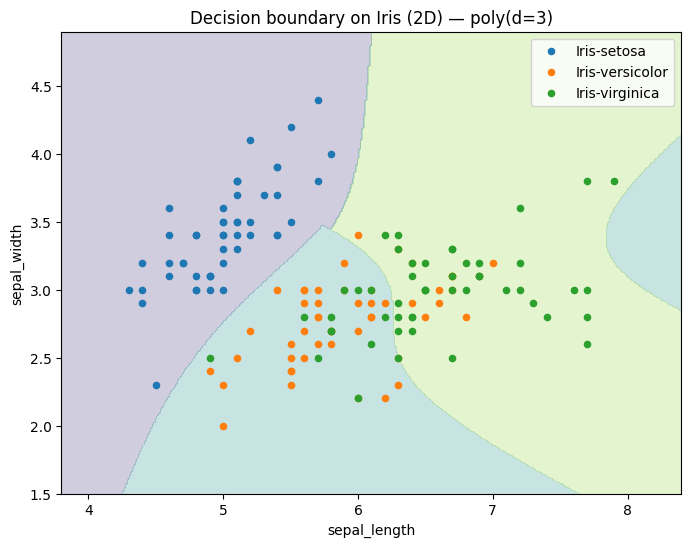

Iris 2D — kernel=rbf(gamma=0.7)
--------------------------------------------------------------------------------
Accuracy: 0.7105

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.92      0.96        12
Iris-versicolor       0.56      0.69      0.62        13
 Iris-virginica       0.64      0.54      0.58        13

       accuracy                           0.71        38
      macro avg       0.73      0.72      0.72        38
   weighted avg       0.73      0.71      0.71        38



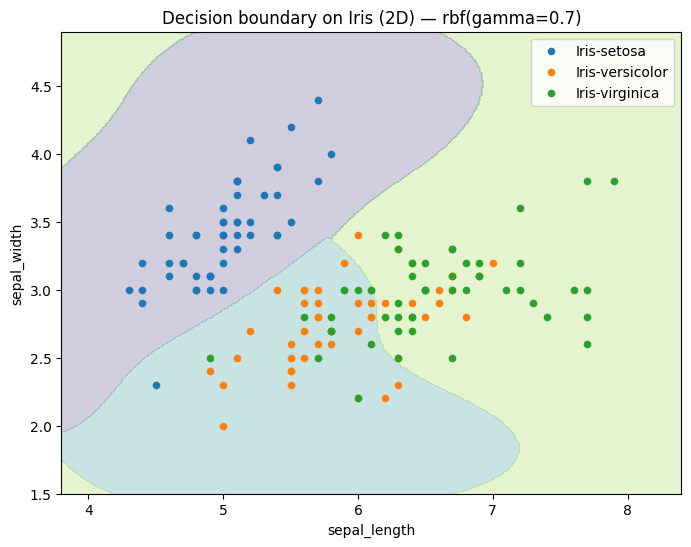

Iris 2D — kernel=sigmoid
--------------------------------------------------------------------------------
Accuracy: 0.8158

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       0.92      1.00      0.96        12
Iris-versicolor       0.75      0.69      0.72        13
 Iris-virginica       0.77      0.77      0.77        13

       accuracy                           0.82        38
      macro avg       0.81      0.82      0.82        38
   weighted avg       0.81      0.82      0.81        38



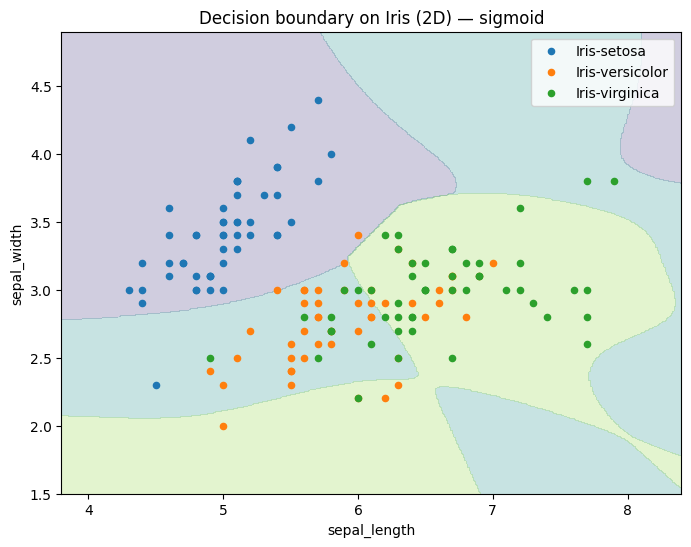

In [5]:
# --- Example 1: Visual intuition on Iris (2D) ---
iris = load_csv(PATH_IRIS)
display(iris.head())

features = ["sepal_length", "sepal_width"]
X = iris[features].values
y = iris["classification"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

kernels = {
    "linear": SVC(kernel="linear", C=1.0),
    "poly(d=3)": SVC(kernel="poly", degree=3, gamma="scale", C=1.0, coef0=1.0),
    "rbf(gamma=0.7)": SVC(kernel="rbf", gamma=0.7, C=1.0),
    "sigmoid": SVC(kernel="sigmoid", gamma="scale", C=1.0, coef0=0.0)
}

for name, clf in kernels.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", clf)
    ])
    train_test_report(pipe, X_train, X_test, y_train, y_test, title=f"Iris 2D — kernel={name}")

    pipe.fit(X, y)
    plot_decision_boundary_2d(pipe, X, y, feature_names=tuple(features), title=f"Decision boundary on Iris (2D) — {name}")

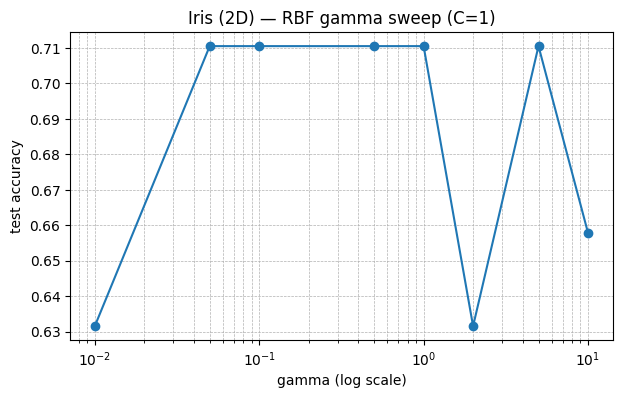

   gamma  test_accuracy
0   0.01       0.631579
1   0.05       0.710526
2   0.10       0.710526
3   0.50       0.710526
4   1.00       0.710526
5   2.00       0.631579
6   5.00       0.710526
7  10.00       0.657895


In [6]:
# --- Iris: sweep gamma for RBF to see smooth vs wiggly boundaries ---
iris = load_csv(PATH_IRIS)
features = ["sepal_length", "sepal_width"]
X = iris[features].values
y = iris["classification"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

gammas = [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10]
accs = []

for g in gammas:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", gamma=g, C=1.0))
    ])
    pipe.fit(X_train, y_train)
    accs.append(pipe.score(X_test, y_test))

plt.figure(figsize=(7, 4))
plt.plot(gammas, accs, marker="o")
plt.xscale("log")
plt.xlabel("gamma (log scale)")
plt.ylabel("test accuracy")
plt.title("Iris (2D) — RBF gamma sweep (C=1)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

print(pd.DataFrame({"gamma": gammas, "test_accuracy": accs}))

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,building_windows_float_processed
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,building_windows_float_processed
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,building_windows_float_processed
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,building_windows_float_processed
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,building_windows_float_processed


Glass — linear
--------------------------------------------------------------------------------
Accuracy: 0.6667

Classification report:
                                      precision    recall  f1-score   support

    building_windows_float_processed       0.57      0.72      0.63        18
building_windows_non_float_processed       0.63      0.63      0.63        19
                          containers       1.00      0.67      0.80         3
                           headlamps       1.00      1.00      1.00         8
                           tableware       0.50      0.50      0.50         2
     vehicle_windows_float_processed       0.00      0.00      0.00         4

                            accuracy                           0.67        54
                           macro avg       0.62      0.59      0.59        54
                        weighted avg       0.63      0.67      0.64        54

Glass — rbf
--------------------------------------------------------------------

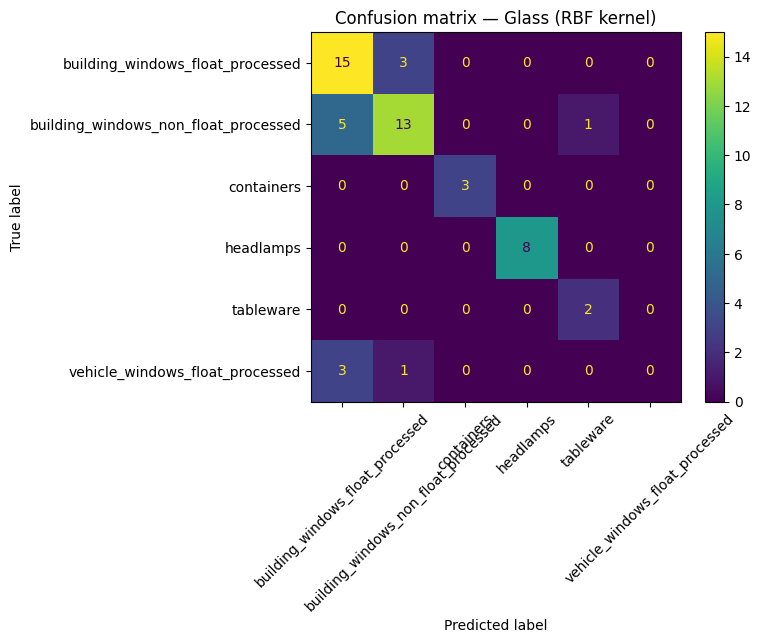

In [7]:
# --- Example 2: Multi-class SVM with kernels on Glass ---
glass = load_csv(PATH_GLASS)
display(glass.head())

X = glass.drop(columns=["Type"])
y = glass["Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

candidates = [
    ("linear", SVC(kernel="linear", C=2.0)),
    ("rbf", SVC(kernel="rbf", gamma="scale", C=5.0)),
    ("poly", SVC(kernel="poly", degree=3, gamma="scale", C=3.0, coef0=1.0)),
]

for name, svc in candidates:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", svc)
    ])
    train_test_report(pipe, X_train, X_test, y_train, y_test, title=f"Glass — {name}")

best_pipe = Pipeline([("scaler", StandardScaler()), ("svc", SVC(kernel="rbf", gamma="scale", C=5.0))])
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=best_pipe.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_pipe.classes_)
disp.plot(xticks_rotation=45)
plt.title("Confusion matrix — Glass (RBF kernel)")
plt.show()

In [8]:
# --- Example 3: Diabetes + kernel choice via CV ---
diab = load_csv(PATH_DIABETES)
display(diab.head())

X = diab.drop(columns=["classification"])
y = diab["classification"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC())
])

param_grid = {
    "svc__kernel": ["linear", "rbf", "poly"],
    "svc__C": [0.1, 1, 10, 50],
    "svc__gamma": ["scale", "auto", 0.01, 0.1, 1.0],
    "svc__degree": [2, 3],
    "svc__coef0": [0.0, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=0
)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

y_pred = grid.predict(X_test)
print("\nTest accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,classification
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


Best params: {'svc__C': 1, 'svc__coef0': 0.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}
Best CV accuracy: 0.7742428785607196

Test accuracy: 0.7604166666666666

Classification report:
              precision    recall  f1-score   support

    Diabetic       0.71      0.52      0.60        67
Non-Diabetic       0.78      0.89      0.83       125

    accuracy                           0.76       192
   macro avg       0.75      0.71      0.72       192
weighted avg       0.75      0.76      0.75       192



In [9]:
# --- Example 4: Stars dataset (mixed numeric + categorical) with kernel SVM ---
stars = load_csv(PATH_STARS)
display(stars.head())

# Target: Type (as in the CSV)
y = stars["Type"]
X = stars.drop(columns=["Type"])

num_cols = ["Temperature", "L", "R", "A_M"]
cat_cols = ["Color", "Spectral_Class"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

pipe = Pipeline([
    ("prep", preprocess),
    ("svc", SVC(kernel="rbf", gamma="scale", C=5.0))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

train_test_report(pipe, X_train, X_test, y_train, y_test, title="Stars — RBF SVC with OneHotEncoder + scaling")

,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068,0.002400,0.1700,16.12,Red,M,Red Dwarf
1,3042,0.000500,0.1542,16.60,Red,M,Red Dwarf
2,2600,0.000300,0.1020,18.70,Red,M,Red Dwarf
3,2800,0.000200,0.1600,16.65,Red,M,Red Dwarf
4,1939,0.000138,0.1030,20.06,Red,M,Red Dwarf


Stars — RBF SVC with OneHotEncoder + scaling
--------------------------------------------------------------------------------
Accuracy: 0.9833

Classification report:
               precision    recall  f1-score   support

  Brown Dwarf       1.00      1.00      1.00        10
 Hyper Giants       1.00      1.00      1.00        10
Main Sequence       0.91      1.00      0.95        10
    Red Dwarf       1.00      1.00      1.00        10
 Super Giants       1.00      0.90      0.95        10
 White Dwarf        1.00      1.00      1.00        10

     accuracy                           0.98        60
    macro avg       0.98      0.98      0.98        60
 weighted avg       0.98      0.98      0.98        60



array(['White Dwarf ', 'Brown Dwarf', 'Super Giants', 'Red Dwarf',
       'Red Dwarf', 'Brown Dwarf', 'Hyper Giants', 'Hyper Giants',
       'Brown Dwarf', 'Hyper Giants', 'Brown Dwarf', 'Main Sequence',
       'Main Sequence', 'Super Giants', 'Super Giants', 'Brown Dwarf',
       'Brown Dwarf', 'Red Dwarf', 'Super Giants', 'Super Giants',
       'Red Dwarf', 'Hyper Giants', 'Main Sequence', 'White Dwarf ',
       'Hyper Giants', 'White Dwarf ', 'Hyper Giants', 'Super Giants',
       'White Dwarf ', 'Red Dwarf', 'White Dwarf ', 'White Dwarf ',
       'White Dwarf ', 'Super Giants', 'Brown Dwarf', 'Main Sequence',
       'Main Sequence', 'Brown Dwarf', 'Red Dwarf', 'Hyper Giants',
       'Super Giants', 'Red Dwarf', 'Main Sequence', 'Red Dwarf',
       'Red Dwarf', 'Main Sequence', 'Brown Dwarf', 'Hyper Giants',
       'Brown Dwarf', 'Main Sequence', 'White Dwarf ', 'Red Dwarf',
       'Main Sequence', 'Main Sequence', 'White Dwarf ', 'Hyper Giants',
       'Hyper Giants', 'Main Sequenc

## ۱۰) کرنل سفارشی + ماتریس گرام از پیش‌محاسبه‌شده (با مرکزدهی)

وقتی کرنل سفارشی می‌دهید، در واقع هندسه‌ی فضای ویژگی را تعریف می‌کنید. دو گام عملی برای پایداری:

1. **بررسی PSD**: حداقل مقدار ویژه خیلی منفی نباشد (با تلرانس عددی).
2. **مرکزدهی** (اختیاری): $K_c = HKH$ میانگین ویژگی‌ها را حذف می‌کند.

یک کرنل RBF دستی را پیاده‌سازی می‌کنیم و هر دو مورد را نشان می‌دهیم.

In [10]:
# --- Custom kernel: Precomputed Gram matrix + PSD check (and centering) ---
iris = load_csv(PATH_IRIS)
X = iris[["petal_length", "petal_width"]].values
y = iris["classification"].values

def rbf_kernel(x, z, gamma):
    diff = x - z
    return np.exp(-gamma * np.dot(diff, diff))

gamma = 1.0
K = gram_matrix(X, lambda a, b: rbf_kernel(a, b, gamma=gamma))

ok, eigvals = is_psd(K)
print("Is Gram matrix PSD?", ok)
print("Smallest eigenvalues:", np.sort(eigvals)[:5])

# Center the Gram matrix in feature space
Kc = center_gram(K)
ok_c, eigvals_c = is_psd(Kc)
print("\nAfter centering: PSD?", ok_c)
print("Smallest eigenvalues (centered):", np.sort(eigvals_c)[:5])

# Train/test split on indices because SVC with precomputed kernel expects K_train and K_test
idx = np.arange(X.shape[0])
idx_train, idx_test = train_test_split(idx, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

K_train = K[np.ix_(idx_train, idx_train)]
K_test = K[np.ix_(idx_test, idx_train)]

svc_pre = SVC(kernel="precomputed", C=1.0)
svc_pre.fit(K_train, y[idx_train])

y_pred = svc_pre.predict(K_test)
print("\nAccuracy (precomputed RBF):", accuracy_score(y[idx_test], y_pred))

Is Gram matrix PSD? True
Smallest eigenvalues: [-1.13597113e-14 -3.93286710e-15 -2.65352089e-15 -1.69600066e-15
 -1.60606253e-15]

After centering: PSD? True
Smallest eigenvalues (centered): [-6.77469915e-15 -3.46468810e-15 -2.21087102e-15 -1.81083846e-15
 -1.59405230e-15]

Accuracy (precomputed RBF): 0.9473684210526315


## ۱۱) تقریب کرنل: Random Fourier Features (RFF)

SVM کرنلی دقیق می‌تواند از نظر حافظه/زمان سنگین باشد.

RFF کرنل RBF را با یک نگاشت ویژگی صریح تقریب می‌زند:

$$
z(x)^\top z(z') \approx \exp(-\gamma\|x-z'\|^2)
$$

سپس یک مدل خطی در فضای $D$-بعدی آموزش می‌دهیم. با افزایش $D$ معمولاً دقت به RBF دقیق نزدیک می‌شود، در حالی‌که مقیاس‌پذیری بهتر می‌گردد.

In [11]:
# --- Kernel approximation: Random Fourier Features (RFF) for RBF ---
glass = load_csv(PATH_GLASS)
X = glass.drop(columns=["Type"]).values
y = glass["Type"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

D = 1000
gamma = 0.2

rff = RBFSampler(gamma=gamma, n_components=D, random_state=RANDOM_STATE)
linear = LinearSVC(C=1.0)

approx_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("rff", rff),
    ("lin", linear)
])

train_test_report(approx_pipe, X_train, X_test, y_train, y_test, title="Glass — RFF approximation + LinearSVC")

exact_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", gamma=gamma, C=5.0))
])
train_test_report(exact_pipe, X_train, X_test, y_train, y_test, title="Glass — Exact RBF SVC")

Glass — RFF approximation + LinearSVC
--------------------------------------------------------------------------------
Accuracy: 0.7037

Classification report:
                                      precision    recall  f1-score   support

    building_windows_float_processed       0.65      0.72      0.68        18
building_windows_non_float_processed       0.68      0.79      0.73        19
                          containers       1.00      1.00      1.00         3
                           headlamps       1.00      0.75      0.86         8
                           tableware       0.50      0.50      0.50         2
     vehicle_windows_float_processed       0.00      0.00      0.00         4

                            accuracy                           0.70        54
                           macro avg       0.64      0.63      0.63        54
                        weighted avg       0.68      0.70      0.69        54

Glass — Exact RBF SVC
-----------------------------------

array(['building_windows_float_processed', 'containers',
       'building_windows_float_processed',
       'building_windows_non_float_processed', 'headlamps',
       'building_windows_non_float_processed', 'headlamps',
       'building_windows_float_processed',
       'building_windows_float_processed',
       'building_windows_float_processed',
       'building_windows_non_float_processed',
       'building_windows_non_float_processed',
       'building_windows_float_processed',
       'building_windows_float_processed',
       'building_windows_non_float_processed', 'containers',
       'building_windows_float_processed', 'tableware',
       'building_windows_non_float_processed', 'headlamps',
       'building_windows_float_processed',
       'building_windows_float_processed',
       'building_windows_non_float_processed',
       'building_windows_non_float_processed', 'tableware',
       'building_windows_non_float_processed', 'tableware',
       'building_windows_float_processed'

## ۱۲) تمرین‌های کوتاه (با راهنمای حل)

1. **حساسیت مرز تصمیم:** روی Iris دوبعدی، `gamma` را در `{0.01, 0.1, 1, 10}` تغییر دهید و `C=1` را ثابت بگذارید.
2. **مرتبه‌ی چندجمله‌ای:** روی Glass، `degree=2,3,4` را با `C=3` و `gamma="scale"` مقایسه کنید.
3. **اعتبار کرنل:** کرنل دستی را به `exp(+gamma||x-z||^2)` تغییر دهید و مقادیر ویژه را بررسی کنید. آیا PSD است؟
4. **ویژگی‌های دسته‌ای:** روی Stars، کرنل خطی و RBF را بعد از One-Hot مقایسه کنید. آیا غیرخطی کمک می‌کند؟

راهنما: `gamma` بزرگ‌تر پیچیدگی را زیاد می‌کند؛ درجه‌ی بالاتر تعاملات بیشتری می‌سازد؛ کرنل با علامت مثبت معمولاً PSD نیست؛ برای داده‌های one-hot پر‌بُعد، خطی اغلب بسیار رقابتی است.